First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal  

C:\Users\GUE\AppData\Local\Temp\ipykernel_32868\629914777.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


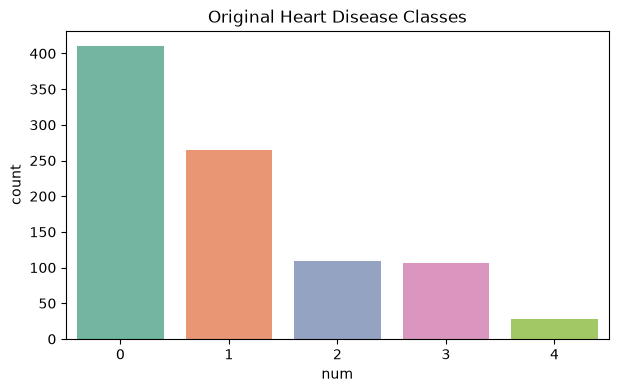

C:\Users\GUE\AppData\Local\Temp\ipykernel_32868\629914777.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


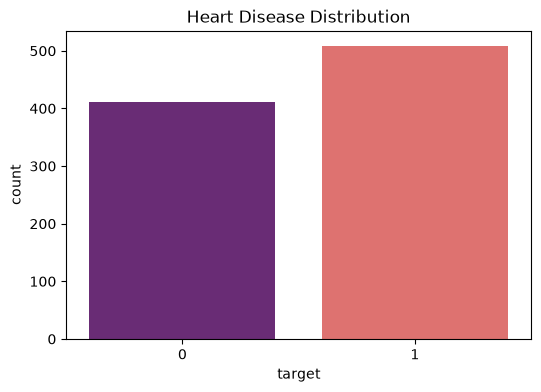

C:\Users\GUE\AppData\Local\Temp\ipykernel_32868\629914777.py:107: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])



Target Counts:
target
1    509
0    411
Name: count, dtype: int64

================ MODEL EVALUATION ================

Accuracy : 0.837
Precision: 0.8273
Recall   : 0.8922
F1 Score : 0.8585

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



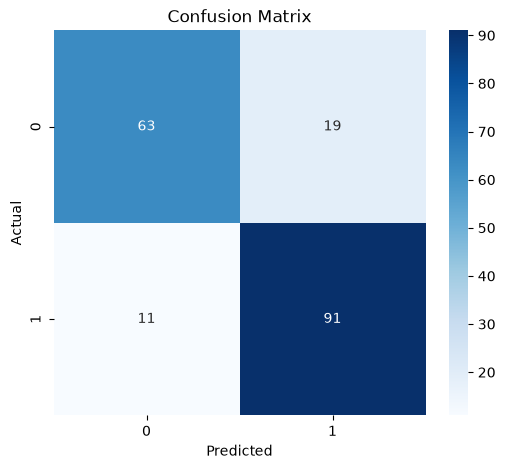

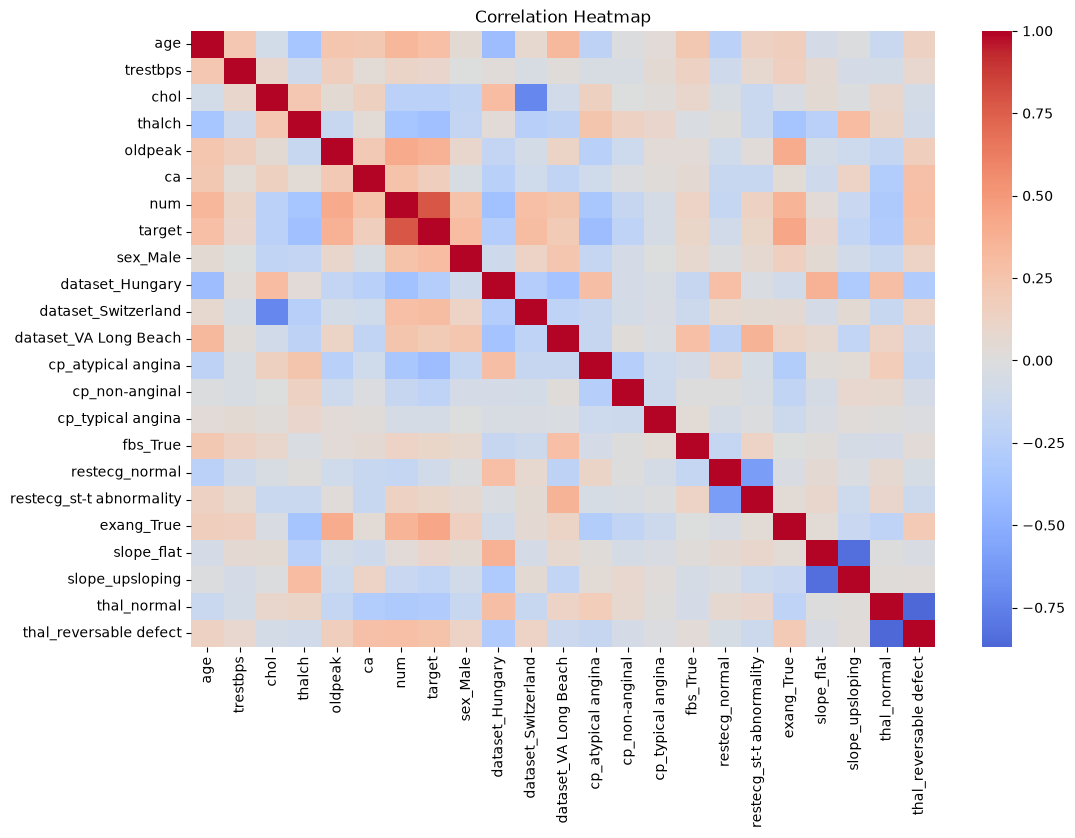


================ CONCLUSION ================

Logistic Regression was used to predict the presence of heart disease. The original target variable 'num' was converted into a binary target. Categorical variables were encoded, missing values were handled, and features were scaled before model training.

The model performance was evaluated using accuracy, precision, recall, F1-score and a confusion matrix.


In [5]:
# ============================================================
# MINI-PROJECT: HEART DISEASE UCI
# LOGISTIC REGRESSION
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------
df = pd.read_csv("heart_disease_uci.csv")

# ------------------------------------------------------------
# 3. EDA
# ------------------------------------------------------------
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

# ------------------------------------------------------------
# 4. TARGET VISUALIZATION
# ------------------------------------------------------------
plt.figure(figsize=(7,4))

sns.countplot(
    x="num",
    data=df,
    palette="Set2"
)

plt.title("Original Heart Disease Classes")
plt.show()

# ------------------------------------------------------------
# 5. CONVERT MULTICLASS TARGET TO BINARY
# 0 = No Heart Disease
# 1 = Heart Disease
# ------------------------------------------------------------
df["target"] = (df["num"] > 0).astype(int)

plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df,
    palette="magma"
)

plt.title("Heart Disease Distribution")
plt.show()

print("\nTarget Counts:")
print(df["target"].value_counts())

# ------------------------------------------------------------
# 6. DROP USELESS COLUMNS
# ------------------------------------------------------------
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

# ------------------------------------------------------------
# 7. HANDLE MISSING VALUES
# ------------------------------------------------------------
# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ------------------------------------------------------------
# 8. ENCODE CATEGORICAL VARIABLES
# ------------------------------------------------------------
df = pd.get_dummies(
    df,
    columns=[
        "sex",
        "dataset",
        "cp",
        "fbs",
        "restecg",
        "exang",
        "slope",
        "thal"
    ],
    drop_first=True
)

# ------------------------------------------------------------
# 9. FEATURES AND TARGET
# ------------------------------------------------------------
X = df.drop(["num", "target"], axis=1)

y = df["target"]

# ------------------------------------------------------------
# 10. FEATURE SCALING
# ------------------------------------------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 11. TRAIN TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 12. TRAIN LOGISTIC REGRESSION
# ------------------------------------------------------------
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

# ------------------------------------------------------------
# 13. PREDICTIONS
# ------------------------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------------------------
# 14. EVALUATION METRICS
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n================ MODEL EVALUATION ================\n")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

# ------------------------------------------------------------
# 15. CLASSIFICATION REPORT
# ------------------------------------------------------------
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ------------------------------------------------------------
# 16. CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ------------------------------------------------------------
# 17. FEATURE CORRELATION HEATMAP
# ------------------------------------------------------------
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

# ------------------------------------------------------------
# 18. CONCLUSION
# ------------------------------------------------------------
print("\n================ CONCLUSION ================\n")

print(
    "Logistic Regression was used to predict the presence "
    "of heart disease. The original target variable 'num' "
    "was converted into a binary target. Categorical "
    "variables were encoded, missing values were handled, "
    "and features were scaled before model training."
)

print(
    "\nThe model performance was evaluated using "
    "accuracy, precision, recall, F1-score and a "
    "confusion matrix."
)